# Logistic Regression Model using Word2Vec static embedding
**Train on Mendeley data, Test on Kaggle data**

In [2]:
import json
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yuhan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yuhan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# ============ LOAD DATA ============
print("Loading data...")

# Load training data (Mendeley)
with open('../cleaned_data/mendeley_cleaned.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load test data (Kaggle)
with open('../cleaned_data/kaggle_data.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Training samples (Mendeley): {len(train_data):,}")
print(f"Test samples (Kaggle): {len(test_data):,}")

Loading data...
Training samples (Mendeley): 53,920
Test samples (Kaggle): 117,458


In [5]:
# ============ PREPARE DATA ============
# Extract features and labels
X_train = [item['review'] for item in train_data]
y_train = [1 if item['recommend'] == 'Recommended' else 0 for item in train_data]

X_test = [item['review_content'] for item in test_data]
y_test = [1 if item['is_positive'] else 0 for item in test_data]

print(f"Training set - Positive: {sum(y_train):,}, Negative: {len(y_train) - sum(y_train):,}")
print(f"Test set - Positive: {sum(y_test):,}, Negative: {len(y_test) - sum(y_test):,}")

Training set - Positive: 26,960, Negative: 26,960
Test set - Positive: 55,789, Negative: 61,669


In [10]:
# ============ VECTORIZE TEXT ============
print("Vectorizing text with Gensim Word2Vec...")

stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalpha() and word.isascii() and word not in stop_words]

w2v_model = Word2Vec(
    sentences=[preprocess_text(review) for review in X_train], 
    vector_size=64, 
    workers=4,
    sg=1, # use skip-gram rather than CBOW
    negative=5,
    epochs=5,
)

# Document embeddings by averaging word vectors
def document_embedding(doc):
    tokens = preprocess_text(doc)
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v_model.vector_size)

X_train_embedded = np.array([document_embedding(doc) for doc in X_train])
X_test_embedded = np.array([document_embedding(doc) for doc in X_test])

print("Word2Vec vocab size:", len(w2v_model.wv))
print("Embedding dimension:", w2v_model.vector_size)

Vectorizing text with Gensim Word2Vec...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec vocab size: 13101
Embedding dimension: 64


Visualizing embeddings with t-SNE...
Embedding matrix shape for t-SNE: (2000, 64)


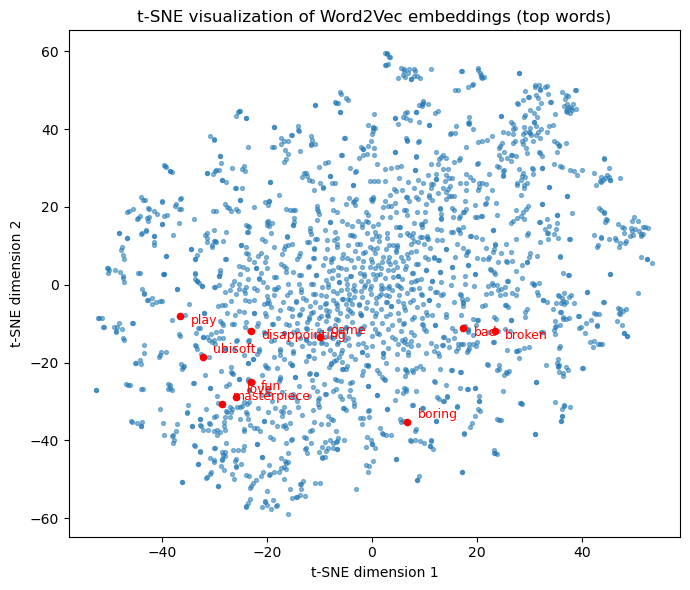

In [11]:
# =========== TNSE VISUALIZATION ===========
print("Visualizing embeddings with t-SNE...")

TOP_N_TOKENS_TSNE = 2000

vocab_words = list(w2v_model.wv.index_to_key[:TOP_N_TOKENS_TSNE])
emb_matrix = np.stack([w2v_model.wv[w] for w in vocab_words])

print("Embedding matrix shape for t-SNE:", emb_matrix.shape)

tsne_coords = TSNE(n_components=2,
                perplexity=30.0,
                max_iter=1000,
                random_state=42).fit_transform(emb_matrix)

plt.figure(figsize=(7, 6))
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], s=8, alpha=0.5)

label_words = ["masterpiece", "fun", "love", "bad", "unenjoyable", "disappointing", "boring", "broken", "game", "play", "ubisoft"]
for i, word in enumerate(label_words):
    if word in vocab_words:
        idx = vocab_words.index(word)
        x, y = tsne_coords[idx]
        plt.scatter([x], [y], color="red", s=20)
        plt.text(x + 2, y + 1 - 3 * (i%2), word, fontsize=9, color="red")

plt.title("t-SNE visualization of Word2Vec embeddings (top words)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

In [12]:
# ============ TRAIN MODEL ============
print("Training Logistic Regression model...")
model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_embedded, y_train)
print("Training complete!")

Training Logistic Regression model...
Training complete!


c:\Users\yuhan\miniconda3\envs\cs175\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [16]:
# ============ EVALUATE ON TEST SET ============
print("=" * 50)
print("EVALUATION ON KAGGLE TEST SET")
print("=" * 50)

y_pred = model.predict(X_test_embedded)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test_embedded)[:, 1])
roc_auc = metrics.auc(fpr, tpr)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {roc_auc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

EVALUATION ON KAGGLE TEST SET

Accuracy:  0.7588
Precision: 0.7500
Recall:    0.7384
F1 Score:  0.7441
AUC:       0.8287

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.77      0.78      0.77     61669
    Positive       0.75      0.74      0.74     55789

    accuracy                           0.76    117458
   macro avg       0.76      0.76      0.76    117458
weighted avg       0.76      0.76      0.76    117458



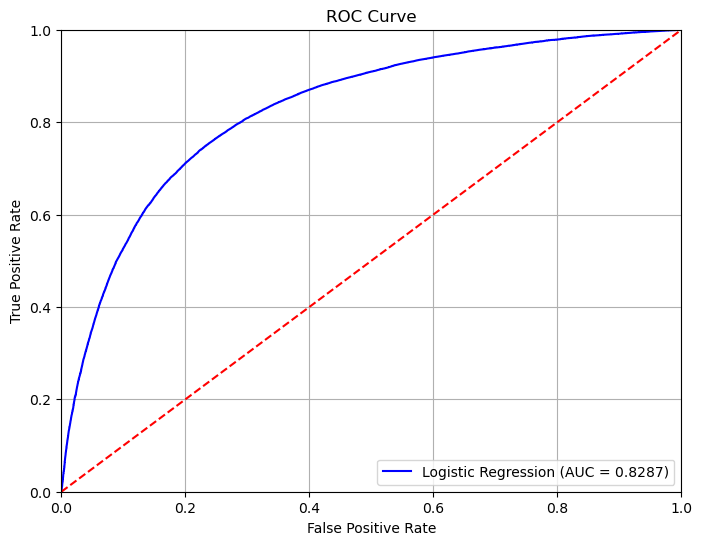

In [17]:
# ============ AUC-ROC CURVE ============
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

--- Confusion Matrix ---
[[47934 13735]
 [14593 41196]]


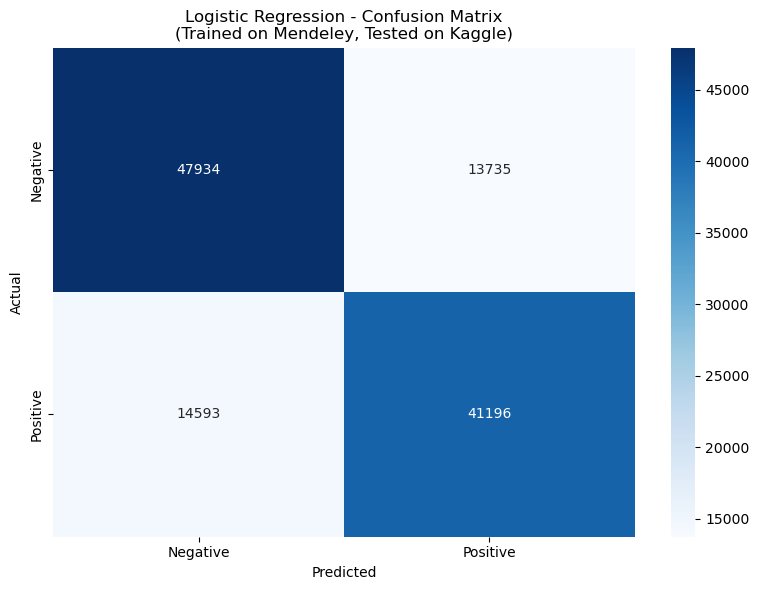

In [18]:
# ============ CONFUSION MATRIX ============
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle)')
plt.tight_layout()
plt.show()

In [ ]:
# ============ RESULTS SUMMARY ============
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Model: Logistic Regression")
print(f"Train data: Mendeley cleaned ({len(train_data):,} samples)")
print(f"Test data: Kaggle cleaned ({len(test_data):,} samples)")
print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC:       {roc_auc:.4f}")

RESULTS SUMMARY
Model: Logistic Regression
Train data: Mendeley cleaned (53,920 samples)
Test data: Kaggle cleaned (117,458 samples)

Metrics:
  Accuracy:  0.7588
  Precision: 0.7500
  Recall:    0.7384
  F1 Score:  0.7441
